# 数据的导入与导出

In [1]:
import os
import pandas as pd

os.makedirs("data", exist_ok=True)
df = pd.DataFrame({"age": [20, 30, 40, 10], "name": ["张三", "李四", "王五", "赵六"], "id": [101, 102, 103, 104]})
df.set_index("id", inplace=True)
df.to_csv("data/df.csv")
df.to_csv("data/df.tsv", sep="\t")
df.to_csv("data/df_noindex.csv", index=False)
df.to_pickle("data/df.pkl")
df.to_excel("data/df.xlsx")
df.to_clipboard()
df.to_hdf("data/df.h5", key="df")
df.to_feather("data/df.feather")

In [4]:
df_csv = pd.read_csv("data/df.csv", index_col="id")
df_tsv = pd.read_csv("data/df.tsv", sep="\t")
df_pkl = pd.read_pickle("data/df.pkl")
df_excel = pd.read_excel("data/df.xlsx", index_col="id")
# df_clipboard=pd.read_clipboard(index_col="id")
df_hdf = pd.read_hdf("data/df.h5", key="df")
df_feather = pd.read_feather("data/df.feather")
print(df_csv)
print(df_tsv)
print(df_pkl)
print(df_excel)
# print(df_clipboard)
print(df_hdf)
print(df_feather)

     age name
id           
101   20   张三
102   30   李四
103   40   王五
104   10   赵六
    id  age name
0  101   20   张三
1  102   30   李四
2  103   40   王五
3  104   10   赵六
     age name
id           
101   20   张三
102   30   李四
103   40   王五
104   10   赵六
     age name
id           
101   20   张三
102   30   李四
103   40   王五
104   10   赵六
     age name
id           
101   20   张三
102   30   李四
103   40   王五
104   10   赵六
     age name
id           
101   20   张三
102   30   李四
103   40   王五
104   10   赵六


# 数据清洗与预处理

## 1.  缺失值处理

In [5]:
import numpy as np
import pandas as pd

s = pd.Series([np.nan, None, pd.NA])
print(s)
print(s.isnull())

0     NaN
1    None
2    <NA>
dtype: object
0    True
1    True
2    True
dtype: bool


In [15]:
import pandas as pd

df = pd.read_csv("data/weather_withna.csv")
print(df.tail(5))

            date  precipitation  temp_max  temp_min  wind weather
1456  2015-12-27            NaN       NaN       NaN   NaN     NaN
1457  2015-12-28            NaN       NaN       NaN   NaN     NaN
1458  2015-12-29            NaN       NaN       NaN   NaN     NaN
1459  2015-12-30            NaN       NaN       NaN   NaN     NaN
1460  2015-12-31           20.6      12.2       5.0   3.8    rain


In [16]:
# 可以通过keep_default_na参数设置是否将空白值设置为缺失值。
df = pd.read_csv("data/weather_withna.csv", keep_default_na=False)
print(df.tail(5))

            date precipitation temp_max temp_min wind weather
1456  2015-12-27                                             
1457  2015-12-28                                             
1458  2015-12-29                                             
1459  2015-12-30                                             
1460  2015-12-31          20.6     12.2      5.0  3.8    rain


In [17]:
# 可通过na_values参数将指定值设置为缺失值
df = pd.read_csv("data/weather_withna.csv", na_values=["2015-12-31"])
print(df.tail(5))

            date  precipitation  temp_max  temp_min  wind weather
1456  2015-12-27            NaN       NaN       NaN   NaN     NaN
1457  2015-12-28            NaN       NaN       NaN   NaN     NaN
1458  2015-12-29            NaN       NaN       NaN   NaN     NaN
1459  2015-12-30            NaN       NaN       NaN   NaN     NaN
1460         NaN           20.6      12.2       5.0   3.8    rain


In [18]:
df = pd.read_csv("data/weather_withna.csv")
print(df.isnull().sum())

date               0
precipitation    303
temp_max         303
temp_min         303
wind             303
weather          303
dtype: int64


In [21]:
# 通过dropna()方法来剔除缺失值。
# Series剔除缺失值
s = pd.Series([25, pd.NA, None])
print(s)
print(s.dropna())

0      25
1    <NA>
2    None
dtype: object
0    25
dtype: object


In [22]:
# DataFrame剔除缺失值
# 无法从DataFrame中单独剔除一个值，只能剔除缺失值所在的整行或整列。默认情况下，dropna()会剔除任何包含缺失值的整行数据。
df = pd.DataFrame([[25, pd.NA, 65], [2, 3, 5], [pd.NA, 4, 6]])
print(df)
print(df.dropna())

      0     1   2
0    25  <NA>  65
1     2     3   5
2  <NA>     4   6
   0  1  2
1  2  3  5


In [23]:
# 可以设置按不同的坐标轴剔除缺失值，比如axis=1（或 axis='columns'）会剔除任何包含缺失值的整列数据。
df = pd.DataFrame([[25, pd.NA, 65], [2, 3, 5], [pd.NA, 4, 6]])
print(df)
print(df.dropna(axis=1))

      0     1   2
0    25  <NA>  65
1     2     3   5
2  <NA>     4   6
    2
0  65
1   5
2   6


In [24]:
# 有时只需要剔除全部是缺失值的行或列，或者绝大多数是缺失值的行或列。这些需求可以通过设置how或thresh参数来满足，它们可以设置剔除行或列缺失值的数量阈值。
df = pd.DataFrame([[18, pd.NA, 26], [pd.NA, pd.NA, 55], [pd.NA, pd.NA, pd.NA]])
print(df)
print(df.dropna(how="all"))  # 如果所有值都是缺失值,则删除这一行
print(df.dropna(thresh=2))  # 如果至少有2个值不是缺失值,则保留这一行

      0     1     2
0    18  <NA>    26
1  <NA>  <NA>    55
2  <NA>  <NA>  <NA>
      0     1   2
0    18  <NA>  26
1  <NA>  <NA>  55
    0     1   2
0  18  <NA>  26


In [25]:
# 可以通过设置subset参数来设置某一列有缺失值则进行剔除。
df = pd.DataFrame([[1, pd.NA, 2], [pd.NA, pd.NA, 5], [pd.NA, pd.NA, pd.NA]])
print(df)
print(df.dropna(subset=[0]))  # 如果0列有缺失值,则删除这一行

      0     1     2
0     1  <NA>     2
1  <NA>  <NA>     5
2  <NA>  <NA>  <NA>


In [5]:
import pandas as pd

# 124. 使用固定值填充
# 通过fillna()方法，传入值或字典进行填充
df = pd.read_csv("data/weather_withna.csv")
print(df.fillna(0).tail())  # 使用固定值填充
print(df.fillna({"temp_max": 60, "temp_min": -60}).tail())  # 使用字典来填充
# 125.	使用统计值填充
# 通过fillna()方法，传入统计后的值进行填充
print(df.fillna(df[["precipitation", "temp_max", "temp_min", "wind"]].mean()).tail())
# 126.	使用前后的有效值填充
# 通过ffill()或bfill()方法使用前面或后面的有效值填充。
print(df.ffill().tail())
print(df.bfill().tail())

            date  precipitation  temp_max  temp_min  wind weather
1456  2015-12-27            0.0       0.0       0.0   0.0       0
1457  2015-12-28            0.0       0.0       0.0   0.0       0
1458  2015-12-29            0.0       0.0       0.0   0.0       0
1459  2015-12-30            0.0       0.0       0.0   0.0       0
1460  2015-12-31           20.6      12.2       5.0   3.8    rain
            date  precipitation  temp_max  temp_min  wind weather
1456  2015-12-27            NaN      60.0     -60.0   NaN     NaN
1457  2015-12-28            NaN      60.0     -60.0   NaN     NaN
1458  2015-12-29            NaN      60.0     -60.0   NaN     NaN
1459  2015-12-30            NaN      60.0     -60.0   NaN     NaN
1460  2015-12-31           20.6      12.2       5.0   3.8    rain
            date  precipitation   temp_max  temp_min      wind weather
1456  2015-12-27       3.052332  15.851468  7.877202  3.242055     NaN
1457  2015-12-28       3.052332  15.851468  7.877202  3.242055    

In [10]:
import pandas as pd
import numpy as np

# 通过线性插值填充
#interpolate 方法支持多种插值方法，可通过 method 参数指定，常见的方法有：
#•	'linear'：线性插值，基于两点之间的直线来估算缺失值，适用于数据呈线性变化的情况。
#•	'time'：适用于时间序列数据，会考虑时间间隔进行插值。
#•	'polynomial'：多项式插值，通过拟合多项式曲线来估算缺失值，可通过 order 参数指定多项式的阶数。

s = pd.Series([1, np.nan, 3, 4, np.nan, 6])
s_interpolated = s.interpolate()
print(s_interpolated)

0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
5    6.0
dtype: float64


In [26]:
import pandas as pd
import numpy as np

s = pd.Series([np.nan, None, pd.NA, 2, 4])
df = pd.DataFrame([[1, pd.NA, 2], [2, 3, 5], [pd.NA, 4, 6]])
print(s)
print(s.isnull())
print(s.isna())
print(s.isna().sum())
print(s.isna().count())
# 剔除缺失值
print(s.dropna())
print(df)
print(df.dropna())  #只要有缺失值，就剔除一整条记录
print(df.dropna(how="all"))
print(df.dropna(thresh=2))
print(df.dropna(axis=1))
print(df.dropna(subset=[0]))  # 如果0列有缺失值,则删除这一行
#填充缺失值
print('*' * 30)
df = pd.read_csv("data/weather_withna.csv")
# df = df.fillna({"temp_max": 60, "temp_min": -60}) # 使用字典来填充
print(df['temp_max'].mean())
df.fillna(df[["precipitation", "temp_max", "temp_min", "wind"]].mean()).tail()
print(df.ffill().tail())
print(df.bfill().tail())

df1 = pd.read_csv("data/weather_withna.csv")
df2 = pd.read_csv("data/weather_withna.csv",
                  keep_default_na=False)  #keep_default_na=False：空白 → "" → 不会被 isnull() 检测到，count() 会统计
print('*' * 50)
print(df1.temp_max.count())
print(df1.isnull().sum())  #sum()：对每列的 True 求和，得到每列的缺失值总数。
print(df2.temp_max.count())  #count()：统计该列中非缺失值（非 NaN） 的数量
print(df2.isnull().sum())

df = pd.read_csv("data/weather_withna.csv", na_values=["2025-12-31"])
print(df.tail(5))
print(df.isnull().sum())

0     NaN
1    None
2    <NA>
3       2
4       4
dtype: object
0     True
1     True
2     True
3    False
4    False
dtype: bool
0     True
1     True
2     True
3    False
4    False
dtype: bool
3
5
3    2
4    4
dtype: object
      0     1  2
0     1  <NA>  2
1     2     3  5
2  <NA>     4  6
   0  1  2
1  2  3  5
      0     1  2
0     1  <NA>  2
1     2     3  5
2  <NA>     4  6
      0     1  2
0     1  <NA>  2
1     2     3  5
2  <NA>     4  6
   2
0  2
1  5
2  6
   0     1  2
0  1  <NA>  2
1  2     3  5
******************************
15.85146804835924
            date  precipitation  temp_max  temp_min  wind weather
1456  2015-12-27            0.0      11.1       4.4   4.8     sun
1457  2015-12-28            0.0      11.1       4.4   4.8     sun
1458  2015-12-29            0.0      11.1       4.4   4.8     sun
1459  2015-12-30            0.0      11.1       4.4   4.8     sun
1460  2015-12-31           20.6      12.2       5.0   3.8    rain
            date  precipitation  temp

## 2. 重复数据处理

In [28]:
#  检测重复行
import pandas as pd

data = {
    'Name': ['Alice', 'Bob', 'Alice', 'Charlie', 'Bob'],
    'Age': [25, 30, 25, 35, 30],
    'City': ['NY', 'LA', 'NY', 'SF', 'LA']
}
df = pd.DataFrame(data)

# 检测重复行（默认检查所有列）
print("重复行标记（False表示首次出现，True表示重复）：")
print(df.duplicated())

重复行标记（False表示首次出现，True表示重复）：
0    False
1    False
2     True
3    False
4     True
dtype: bool


In [29]:
# 删除重复行
df_unique = df.drop_duplicates()
print("去重后的DataFrame：")
print(df_unique)

去重后的DataFrame：
      Name  Age City
0    Alice   25   NY
1      Bob   30   LA
3  Charlie   35   SF


In [30]:
#  按指定列去重
# 仅根据'Name'列去重（保留首次出现）
df_name_unique = df.drop_duplicates(subset=['Name'])
print("按Name列去重：")
print(df_name_unique)

按Name列去重：
      Name  Age City
0    Alice   25   NY
1      Bob   30   LA
3  Charlie   35   SF


In [31]:
# 保留最后一次出现的重复行
df_last = df.drop_duplicates(keep='last')
print("保留最后一次出现的行：")
print(df_last)

保留最后一次出现的行：
      Name  Age City
2    Alice   25   NY
3  Charlie   35   SF
4      Bob   30   LA


## 3. 数据类型转换

In [32]:
# 查看数据类型
import pandas as pd

df = pd.read_csv("data/sleep.csv")
print(df.dtypes)

person_id                    int64
gender                      object
age                          int64
occupation                  object
sleep_duration             float64
sleep_quality              float64
physical_activity_level      int64
stress_level                 int64
bmi_category                object
blood_pressure              object
heart_rate                   int64
daily_steps                  int64
sleep_disorder              object
dtype: object


In [34]:
# 强制类型转换
# 将sleep_duration从float转为int（丢失小数部分）
df['sleep_duration_int'] = df['sleep_duration'].astype('int32')
# 将gender转为字符串
df['gender_str'] = df['gender'].astype('str')
print(df[['sleep_duration', 'sleep_duration_int', 'gender', 'gender_str']].head())

   sleep_duration  sleep_duration_int  gender gender_str
0             7.4                   7    Male       Male
1             4.2                   4  Female     Female
2             6.1                   6    Male       Male
3             8.3                   8    Male       Male
4             9.1                   9    Male       Male


In [38]:
# 转换为日期时间
df_employees = pd.read_csv("data/employees.csv")
df_employees['fake_date'] = '2023-01-' + df_employees['employee_id'].astype(str).str[:2]
df_employees['fake_date'] = pd.to_datetime(df_employees['fake_date'])
print(df_employees[['employee_id', 'fake_date']].head())

   employee_id  fake_date
0          100 2023-01-10
1          101 2023-01-10
2          102 2023-01-10
3          103 2023-01-10
4          104 2023-01-10


In [39]:
# 转换为分类数据
df['gender'] = df['gender'].astype('category')
print(df['gender'].dtypes)

category


In [40]:
# 数值格式化
# 保留sleep_quality的2位小数
df['sleep_quality_rounded'] = df['sleep_quality'].round(2)
print(df[['sleep_quality', 'sleep_quality_rounded']].head())

   sleep_quality  sleep_quality_rounded
0            7.0                    7.0
1            4.9                    4.9
2            6.0                    6.0
3           10.0                   10.0
4            9.5                    9.5


In [42]:
# 实战案例：处理penguins.csv
df_penguins = pd.read_csv("data/penguins.csv")

# 1. 转换sex为分类类型
df_penguins['sex'] = df_penguins['sex'].astype('category')

# 2. 补全缺失值后转换bill_length_mm为float32
df_penguins['bill_length_mm'] = df_penguins['bill_length_mm'].fillna(0).astype('float32')

# 3. 检查并输出结果
print(df_penguins[['species', 'sex', 'bill_length_mm']].dtypes)

species             object
sex               category
bill_length_mm     float32
dtype: object


## 4. 数据重塑与变形

In [43]:
import pandas as pd

# 示例数据
data = {'Name': ['Alice', 'Bob', 'Charlie'],
        'Age': [25, 30, 35],
        'City': ['NY', 'LA', 'SF']
        }
df = pd.DataFrame(data)
# 行列转置
df_transposed = df.T
print("原始数据:\n", df)
print("\n转置后数据:\n", df_transposed)

原始数据:
       Name  Age City
0    Alice   25   NY
1      Bob   30   LA
2  Charlie   35   SF

转置后数据:
           0    1        2
Name  Alice  Bob  Charlie
Age      25   30       35
City     NY   LA       SF


In [ ]:
# 宽表转长表（**pd.melt()**）
# 将多列合并为键值对形式，适合分析多指标数据。


In [47]:
#数据变形
import pandas as pd

data = {
    'ID': [1, 2],
    'name': ['alice', 'bob'],
    'Math': [90, 85],
    'English': [88, 92],
    'Science': [95, 89]
}
df = pd.DataFrame(data)
print(df)
# print(df.T)   #行列转置
print('*' * 50)
# 宽表转换成长表
df2 = pd.melt(df, id_vars=['ID', 'name'], var_name='科目', value_name='分数')
df2.sort_values('name')
print(df2)
# 长表转宽表
pd.pivot(df2, index=['ID', 'name'], columns='科目', values='分数')

   ID   name  Math  English  Science
0   1  alice    90       88       95
1   2    bob    85       92       89
**************************************************
   ID   name       科目  分数
0   1  alice     Math  90
1   2    bob     Math  85
2   1  alice  English  88
3   2    bob  English  92
4   1  alice  Science  95
5   2    bob  Science  89


,科目,English,Math,Science
ID,name,,,
1,alice,88,90,95
2,bob,92,85,89


In [48]:
# 示例数据（长表）
data = {
    'ID': [1, 1, 1, 2, 2, 2],
    'Subject': ['Math', 'English', 'Science', 'Math', 'English', 'Science'],
    'Score': [90, 88, 95, 85, 92, 89]
}
df = pd.DataFrame(data)
# 长表转宽表（以ID为索引，Subject为列，Score为值）
df_pivoted = df.pivot(index='ID', columns='Subject', values='Score')
print("原始数据:\n", df)
print("\n转换后数据:\n", df_pivoted)

原始数据:
    ID  Subject  Score
0   1     Math     90
1   1  English     88
2   1  Science     95
3   2     Math     85
4   2  English     92
5   2  Science     89

转换后数据:
 Subject  English  Math  Science
ID                             
1             88    90       95
2             92    85       89


In [53]:
# 分列操作（**str.split()**）
data = {
    'Full_Name': ['Alice Smith', 'Bob Johnson', 'Charlie Brown']
}
df = pd.DataFrame(data)
# 拆分Full_Name为FirstName和LastName
df[['First_Name', 'Last_Name']] = df['Full_Name'].str.split(' ', expand=True)
print("原始数据:\n", df[['Full_Name']])
print("\n拆分后数据:\n", df[['First_Name', 'Last_Name']])


原始数据:
        Full_Name
0    Alice Smith
1    Bob Johnson
2  Charlie Brown

拆分后数据:
   First_Name Last_Name
0      Alice     Smith
1        Bob   Johnson
2    Charlie     Brown


In [54]:
df = pd.read_csv("data/sleep.csv")

df = df[['person_id', 'blood_pressure']]
df[['high', 'low']] = df['blood_pressure'].str.split('/', expand=True)
df


,person_id,blood_pressure,high,low
0,1,124/70,124,70
1,2,131/86,131,86
2,3,122/70,122,70
3,4,124/72,124,72
4,5,133/78,133,78
...,...,...,...,...
395,396,118/66,118,66
396,397,132/80,132,80
397,398,125/76,125,76
398,399,130/75,130,75


## 5. 文本数据处理

In [1]:
# 字符串大小写转换
import pandas as pd

data = {'Name': ['ALICE', 'Bob', 'CHARLIE']}
df = pd.DataFrame(data)
df['Name_lower'] = df['Name'].str.lower()
df['Name_upper'] = df['Name'].str.upper()
print(df)

      Name Name_lower Name_upper
0    ALICE      alice      ALICE
1      Bob        bob        BOB
2  CHARLIE    charlie    CHARLIE


In [2]:
# 去除空格
data = {'Text': ['  Hello  ', '  Pandas  ', '  Data  ']}
df = pd.DataFrame(data)
df['Text_stripped'] = df['Text'].str.strip()
print(df)

         Text Text_stripped
0     Hello           Hello
1    Pandas          Pandas
2      Data            Data


In [3]:
# 字符串替换
data = {'Comment': ['Good!', 'Bad?', 'Okay...']}
df = pd.DataFrame(data)
df['Comment_clean'] = df['Comment'].str.replace(r'[!?.]', '', regex=True)
print(df)

   Comment Comment_clean
0    Good!          Good
1     Bad?           Bad
2  Okay...          Okay


In [5]:
# 正则表达式提取
data = {'Info': ['Age:25', 'Height:170cm', 'Weight:65kg']}
df = pd.DataFrame(data)
df['Value'] = df['Info'].str.extract(r'(\d+)')
print(df)

           Info Value
0        Age:25    25
1  Height:170cm   170
2   Weight:65kg    65


In [6]:
# 字符串包含检测
data = {'Review': ['Great product', 'Not good', 'Excellent service']}
df = pd.DataFrame(data)
df['Is_Positive'] = df['Review'].str.contains('good', case=False)
print(df)

              Review  Is_Positive
0      Great product        False
1           Not good         True
2  Excellent service        False


In [8]:
# 实战案例：处理employees.csv
# 清理员工姓名和邮箱数据：
df_employees = pd.read_csv("data/employees.csv")
# 1. 将first_name首字母大写，其余小写
df_employees['first_name'] = df_employees['first_name'].str.capitalize()
# 2. 提取邮箱域名（@后部分）
df_employees['email_domain'] = df_employees['email'].str.extract(r'@(.+)')
print(df_employees[['first_name', 'email', 'email_domain']].head())

  first_name     email email_domain
0     Steven     SKING          NaN
1      N_ann  NKOCHHAR          NaN
2        Lex   LDEHAAN          NaN
3  Alexander   AHUNOLD          NaN
4      Bruce    BERNST          NaN


## 6. 数据分箱与离散化

In [9]:
df = pd.read_csv("data/employees.csv")

df1 = df.iloc[:10]
print(df1['salary'])

salary = pd.cut(df1["salary"], 3)
print(salary)

salary = pd.cut(df1['salary'], [0, 10000, 20000])
print(salary)

df['salary_level'] = pd.cut(df["salary"], bins=3, labels=["low", "medium", "high"])
print(df['salary_level'])

df = pd.read_csv("data/employees.csv")
salary = pd.cut(df["salary"], 3)
print(salary.value_counts())
salary2 = pd.qcut(df["salary"], 3)
print(salary2.value_counts())

df_sleep = pd.read_csv("data/sleep.csv")
bins = [0, 4, 7, 10]
labels = ['差', '中', '好']
df_sleep['quality_level'] = pd.cut(df_sleep['sleep_quality'], bins=bins, labels=labels)
print(df_sleep['quality_level'])
print(df_sleep['quality_level'].value_counts())

0    24000.0
1    17000.0
2    17000.0
3     9000.0
4     6000.0
5     4800.0
6     4800.0
7     4200.0
8    12000.0
9     9000.0
Name: salary, dtype: float64
0    (17400.0, 24000.0]
1    (10800.0, 17400.0]
2    (10800.0, 17400.0]
3     (4180.2, 10800.0]
4     (4180.2, 10800.0]
5     (4180.2, 10800.0]
6     (4180.2, 10800.0]
7     (4180.2, 10800.0]
8    (10800.0, 17400.0]
9     (4180.2, 10800.0]
Name: salary, dtype: category
Categories (3, interval[float64, right]): [(4180.2, 10800.0] < (10800.0, 17400.0] < (17400.0, 24000.0]]
0                   NaN
1    (10000.0, 20000.0]
2    (10000.0, 20000.0]
3        (0.0, 10000.0]
4        (0.0, 10000.0]
5        (0.0, 10000.0]
6        (0.0, 10000.0]
7        (0.0, 10000.0]
8    (10000.0, 20000.0]
9        (0.0, 10000.0]
Name: salary, dtype: category
Categories (2, interval[int64, right]): [(0, 10000] < (10000, 20000]]
0        high
1        high
2        high
3         low
4         low
        ...  
102       low
103       low
104    medium
1

## 7. 其他常用转换

重命名列、索引操作、函数应用、内存优化

In [8]:
import pandas as pd

df = pd.DataFrame({"age": [20, 30, 40, 10], "name": ["张三", "李四", "王五", "赵六"], "id": [101, 102, 103, 104]})
print(df)
#通过set_index()设置行索引
# inplace=True：这是一个布尔类型的参数。当设为 True 时，会直接在原DataFrame上进行修改；若设为 False（默认值），则会返回一个新的 DataFrame，原DataFrame 保持不变
df.set_index("id", inplace=True)  # 设置行索引
print(df)
df.reset_index(inplace=True)  # 重置索引
print(df)
#修改行索引名和列名  个别修改
df.rename(index={101: "一", 102: "二", 103: "三", 104: "四"}, columns={"age": "年龄", "name": "姓名"}, inplace=True)
print(df)
#重新赋值  批量修改
df.index = ["Ⅰ", "Ⅱ", "Ⅲ", "Ⅳ"]
df.columns = ["编号", "年龄", "姓名"]
#添加列,通过 df[“列名”] 添加列。
df["phone"] = ["13333333333", "14444444444", "15555555555", "16666666666"]
#删除列
# 通过 df.drop(“列名”, axis=1) 删除，也可是删除行 axis=0
df.drop("phone", axis=1, inplace=True)  # 删除phone，按列删除，inplace=True表示直接在原对象上修改
print(df)
#通过 del df[“列名”] 删除
# del df["phone"]
print(df)
#插入列 通过 insert(loc, column, value) 插入。该方法没有inplace参数，直接在原数据上修改。
# df.insert(loc=0, column="phone", value=df["年龄"] * df.index)
df.insert(loc=0, column="phone", value=df["年龄"].astype(str) + df.index)
print(df)

   age name   id
0   20   张三  101
1   30   李四  102
2   40   王五  103
3   10   赵六  104
     age name
id           
101   20   张三
102   30   李四
103   40   王五
104   10   赵六
    id  age name
0  101   20   张三
1  102   30   李四
2  103   40   王五
3  104   10   赵六
    id  年龄  姓名
0  101  20  张三
1  102  30  李四
2  103  40  王五
3  104  10  赵六
    编号  年龄  姓名
Ⅰ  101  20  张三
Ⅱ  102  30  李四
Ⅲ  103  40  王五
Ⅳ  104  10  赵六
    编号  年龄  姓名
Ⅰ  101  20  张三
Ⅱ  102  30  李四
Ⅲ  103  40  王五
Ⅳ  104  10  赵六
  phone   编号  年龄  姓名
Ⅰ   20Ⅰ  101  20  张三
Ⅱ   30Ⅱ  102  30  李四
Ⅲ   40Ⅲ  103  40  王五
Ⅳ   10Ⅳ  104  10  赵六


# 时间数据的处理

## 1. 时间戳timestamp
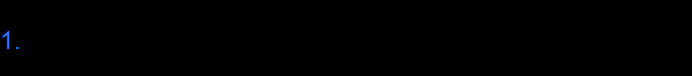

In [11]:
d = pd.Timestamp("2015-05-01 09:08:07.123456")
# 属性
print('年：', d.year)
print('月：', d.month)
print('日：', d.day)
print('小时：', d.hour)
print('分钟：', d.minute)
print('秒：', d.second)
print('微秒：', d.microsecond)
print('季度：', d.quarter)
print('是否是月底：', d.is_month_end)
print('是否是月初：', d.is_month_start)
print('是否是年底：', d.is_year_end)
print('是否是年初：', d.is_year_start)
# 方法
print('星期几：', d.day_name())
print('转换为年度：', d.to_period("Y"))
print('转换为季度：', d.to_period("Q"))
print('转换为月度：', d.to_period("M"))
print('转换为季度：', d.to_period("Q"))
print('转换为周维度：', d.to_period("W"))

年： 2015
月： 5
日： 1
小时： 9
分钟： 8
秒： 7
微秒： 123456
季度： 2
是否是月底： False
是否是月初： True
是否是年底： False
是否是年初： False
星期几： Friday
转换为年度： 2015
转换为季度： 2015Q2
转换为月度： 2015-05
转换为季度： 2015Q2
转换为周维度： 2015-04-27/2015-05-03


## 2.  日期数据转换

In [13]:
# 字符串字段转换为日期类型
a = pd.to_datetime('2025-07-01')
a = pd.to_datetime('20250409')
a = pd.to_datetime('2025/04/13')
a = pd.to_datetime('2025-07')
print(a)
print(type(a))

# dateFrame中的日期转换
df = pd.DataFrame({
    'sales': [100, 50, 40],
    'date': ['2025-01-01', '2023-03-02', '2025-03-09']
})
df['datetime'] = pd.to_datetime(df['date'])
print(type(df['datetime'].dt))
print(df['datetime'].dt.day_name()
      )
# 导入数据日期的处理
df = pd.read_csv("data/weather.csv")
print(df["date"].tail())
print(pd.to_datetime(df["date"]).tail())  # 在加载数据时也可以通过parse_dates参数将指定列解析为datetime64。
df = pd.read_csv("data/weather.csv", parse_dates=[0])
print(df["date"].tail())


2025-07-01 00:00:00
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas.core.indexes.accessors.DatetimeProperties'>
0    Wednesday
1     Thursday
2       Sunday
Name: datetime, dtype: object
1456    2015-12-27
1457    2015-12-28
1458    2015-12-29
1459    2015-12-30
1460    2015-12-31
Name: date, dtype: object
1456   2015-12-27
1457   2015-12-28
1458   2015-12-29
1459   2015-12-30
1460   2015-12-31
Name: date, dtype: datetime64[ns]
1456   2015-12-27
1457   2015-12-28
1458   2015-12-29
1459   2015-12-30
1460   2015-12-31
Name: date, dtype: datetime64[ns]


## 3. 将日期数据作为索引

In [14]:
df = pd.read_csv("data/weather.csv")
df["date"] = pd.to_datetime(df["date"])  # 将date列转换为datetime64类型
df.set_index("date", inplace=True)  # 将date列设置为索引，inplace=true直接修改原对象
df.info()
print(df.loc["2013-01":"2013-06"])  # 获取2013年1~6月的数据
print(df.loc["2015"])  # 获取2015年所有数据
df.between_time("9:00", "11:00")  # 获取9:00到11:00之间的数据
df.at_time("3:33")  # 获取3:33的数据

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1461 entries, 2012-01-01 to 2015-12-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   precipitation  1461 non-null   float64
 1   temp_max       1461 non-null   float64
 2   temp_min       1461 non-null   float64
 3   wind           1461 non-null   float64
 4   weather        1461 non-null   object 
dtypes: float64(4), object(1)
memory usage: 68.5+ KB
            precipitation  temp_max  temp_min  wind weather
date                                                       
2013-01-01            0.0       5.0      -2.8   2.7     sun
2013-01-02            0.0       6.1      -1.1   3.2     sun
2013-01-03            4.1       6.7      -1.7   3.0    rain
2013-01-04            2.5      10.0       2.2   2.8    rain
2013-01-05            3.0       6.7       4.4   3.1    rain
...                   ...       ...       ...   ...     ...
2013-06-26            2.0      22.2

,precipitation,temp_max,temp_min,wind,weather
date,,,,,


## 4. 时间间隔timedelta

In [16]:
d1 = pd.Timestamp("2015-05-01 09:08:07.123456")
d2 = pd.Timestamp("2015-05-31 09:23:07.123456")
print(d2 - d1)
print(type(d1))
print(type(d2 - d1))

df = pd.read_csv("data/weather.csv", parse_dates=[0])
df_date = pd.to_datetime(df["date"])
df["timedelta"] = df_date - df_date[0]  # 得到timedelta64类型的数据
df.set_index("timedelta", inplace=True)  # 将timedelta列设置为索引
df.info()
print(df.loc["0 days":"5 days"])


30 days 00:15:00
<class 'pandas._libs.tslibs.timestamps.Timestamp'>
<class 'pandas._libs.tslibs.timedeltas.Timedelta'>
<class 'pandas.core.frame.DataFrame'>
TimedeltaIndex: 1461 entries, 0 days to 1460 days
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1461 non-null   datetime64[ns]
 1   precipitation  1461 non-null   float64       
 2   temp_max       1461 non-null   float64       
 3   temp_min       1461 non-null   float64       
 4   wind           1461 non-null   float64       
 5   weather        1461 non-null   object        
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 79.9+ KB
                date  precipitation  temp_max  temp_min  wind  weather
timedelta                                                             
0 days    2012-01-01            0.0      12.8       5.0   4.7  drizzle
1 days    2012-01-02           10.9      10.6       2.8   4.5     ra

## 5. 时间序列
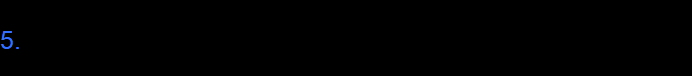

In [18]:
print(pd.date_range("2015-07-03", "2015-07-10"))
print(pd.date_range("2015-07-03", periods=5))
print(pd.date_range("2015-07-03", periods=5, freq="h"))
print(pd.date_range("2015-07-03", periods=10, freq="QE-JAN"))
print(pd.date_range("2015-07-03", periods=10, freq="W-WED"))
print(pd.date_range("2015-07-03", periods=10, freq="2h30min"))

DatetimeIndex(['2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06',
               '2015-07-07', '2015-07-08', '2015-07-09', '2015-07-10'],
              dtype='datetime64[ns]', freq='D')
DatetimeIndex(['2015-07-03', '2015-07-04', '2015-07-05', '2015-07-06',
               '2015-07-07'],
              dtype='datetime64[ns]', freq='D')
DatetimeIndex(['2015-07-03 00:00:00', '2015-07-03 01:00:00',
               '2015-07-03 02:00:00', '2015-07-03 03:00:00',
               '2015-07-03 04:00:00'],
              dtype='datetime64[ns]', freq='h')
DatetimeIndex(['2015-07-31', '2015-10-31', '2016-01-31', '2016-04-30',
               '2016-07-31', '2016-10-31', '2017-01-31', '2017-04-30',
               '2017-07-31', '2017-10-31'],
              dtype='datetime64[ns]', freq='QE-JAN')
DatetimeIndex(['2015-07-08', '2015-07-15', '2015-07-22', '2015-07-29',
               '2015-08-05', '2015-08-12', '2015-08-19', '2015-08-26',
               '2015-09-02', '2015-09-09'],
              dtype='datet

## 6. 重新采样

In [17]:
df = pd.read_csv("data/weather.csv")
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)
print(df[["temp_max", "temp_min"]].resample("YE").mean())  # 将数据按年分组,并计算每年的平均最高最低温度

             temp_max  temp_min
date                           
2012-12-31  15.276776  7.289617
2013-12-31  16.058904  8.153973
2014-12-31  16.995890  8.662466
2015-12-31  17.427945  8.835616


# 数据分析与统计

In [19]:
df = pd.read_csv("data/employees.csv")  # 读取员工数据
print(df.groupby("department_id"))  # 按department_id分组，返回DataFrameGroupBy对象
print(df.groupby("department_id").groups)  # 查看分组结果
print(df.groupby("department_id").get_group(50))  # 获取分组为50的数据
print(df.groupby("department_id")["salary"])  # 按department_id分组，取salary列
print(df.groupby("department_id")["salary"].mean())  # 计算每个部门平均薪资
for dept_id, group in df.groupby("department_id"):
    print(f"当前组为{dept_id}，组里的数据情况{group.shape}:")
    print(group.iloc[:, 0:3])
    print("-------------------")
salary_mean = df.groupby(["department_id", "job_id"])[["salary", "commission_pct"]].mean()  # 按department_id和job_id分组
print(salary_mean.index)  # 查看分组后的索引
print(salary_mean.columns)  # 查看分组后的列
print(salary_mean.reset_index())
salary_mean = df.groupby(["department_id", "job_id"], as_index=False)[["salary", "commission_pct"]].mean() # 按department_id和job_id分组
print(salary_mean)
df["month"] = pd.to_datetime(df["date"]).dt.to_period("M").astype(str)  # 将date转换为 年-月 的格式

df_groupby_date = df.groupby("month")  # 按month分组，返回一个分组对象(DataFrameGroupBy)
month_temp = df_groupby_date[["temp_max", "temp_min"]]  # 从分组对象中选择特定的列
month_temp_mean = month_temp.mean()  # 对每个列求平均值
month_temp_mean = df.groupby("month")[["temp_max", "temp_min"]].mean()
df.groupby("month")["weather"].nunique()

{10.0: [100], 20.0: [101, 102], 30.0: [14, 15, 16, 17, 18, 19], 40.0: [103], 50.0: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99], 60.0: [3, 4, 5, 6, 7], 70.0: [104], 80.0: [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 79], 90.0: [0, 1, 2], 100.0: [8, 9, 10, 11, 12, 13], 110.0: [105, 106]}
    employee_id first_name    last_name     email  phone_number    job_id  \
20          120    Matthew        Weiss    MWEISS  650.123.1234    ST_MAN   
21          121       Adam        Fripp    AFRIPP  650.123.2234    ST_MAN   
22          122      Payam     Kaufling  PKAUFLIN  650.123.3234    ST_MAN   
23          123     Shanta      Vollman  SVOLLMAN  650.123.4234    ST_MAN   
24          124      Kevin      Mourgos  KMOURGOS  650.123.5234    ST_MAN   
25          125      Julia

In [21]:
import numpy as np
df = pd.read_csv("data/employees.csv")  # 读取员工数据
na_index = pd.Series(df.index.tolist()).sample(30)  # 随机挑选30条数据
df.loc[na_index, "salary"] = pd.NA  # 将这30条数据的salary设置为缺失值
print(df.groupby("department_id")["salary"].agg(["size", "count"]))  # 查看每组数据总数与非空数据数

def fill_missing(x):
    # 使用平均值填充，如果平均值也为NaN，用0填充
    if np.isnan(x.mean()):
        return 0
    return x.fillna(x.mean())

df["salary"] = df.groupby("department_id")["salary"].transform(fill_missing)
print(df.groupby("department_id")["salary"].agg(["size", "count"]))  # 查看每组数据总数与非空数据数


               size  count
department_id             
10.0              1      1
20.0              2      2
30.0              6      5
40.0              1      0
50.0             45     29
60.0              5      3
70.0              1      1
80.0             34     28
90.0              3      1
100.0             6      4
110.0             2      2
               size  count
department_id             
10.0              1      1
20.0              2      2
30.0              6      6
40.0              1      1
50.0             45     45
60.0              5      5
70.0              1      1
80.0             34     34
90.0              3      3
100.0             6      6
110.0             2      2
